采样后各类别样本数量： [25 25]
原始数据形状： (50, 30)
使用的特征数量： 30
经典MDS聚类标签: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0]
经典MDS耗时: 1.6306 秒
真实标签 vs 经典MDS NMI: 0.6770
手动MDS耗时: 0.0400 秒
手动MDS vs 真实标签 NMI: 0.6770
手动MDS vs 经典MDS NMI: 1.0000
量子MDS矩阵条件数: 9.463460489320083e+177
-0.08707243925539121 0.08707243925539121
(300, 300)
Ising矩阵形状: (301, 301)
[2026-05-24 21:50:46] [INFO    ] [kaiwu.cim._optimizer_adapter:146] - Task submit successfully, waiting for data validation. Task name: breast_cancer_mds
任务已提交，等待CIM计算...
[2026-05-24 21:50:47] [INFO    ] [kaiwu.cim._optimizer_adapter:153] - Task is still processing: breast_cancer_mds
等待CIM结果，已等待 2 秒...
[2026-05-24 21:50:49] [INFO    ] [kaiwu.cim._optimizer_adapter:153] - Task is still processing: breast_cancer_mds
等待CIM结果，已等待 4 秒...
[2026-05-24 21:50:51] [INFO    ] [kaiwu.cim._optimizer_adapter:153] - Task is still processing: breast_cancer_mds
等待CIM结果，已等待 6 秒...
[2026-05-24 21:50:53] [INFO    ] [kaiwu.cim

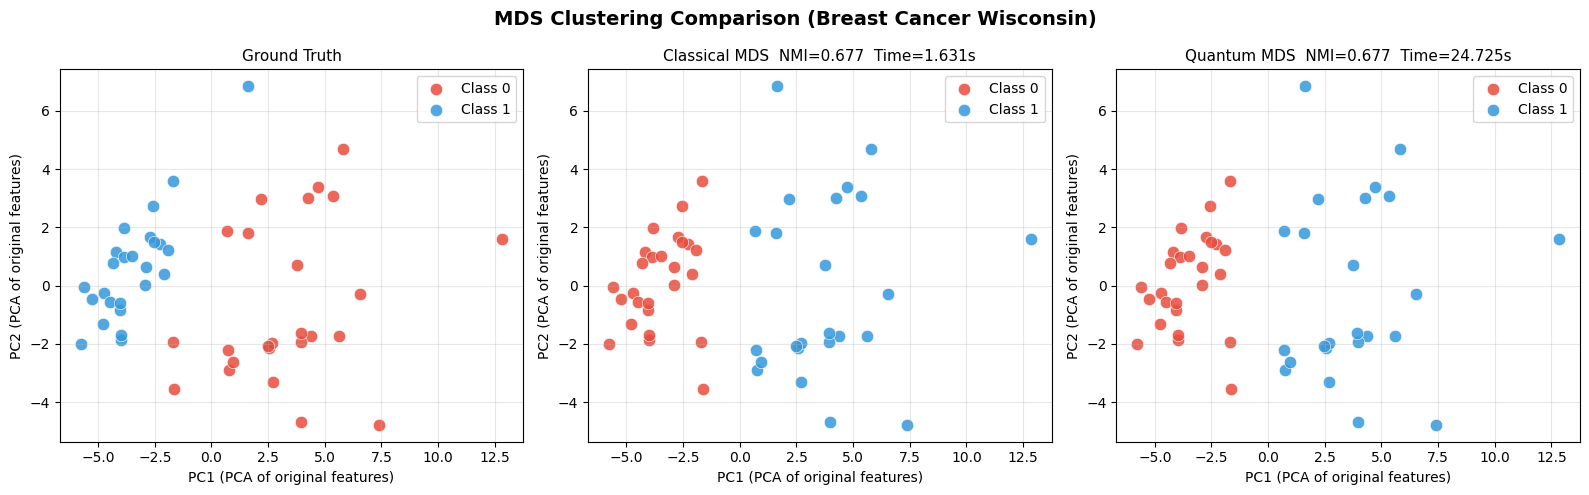

Saved: results/mds_comparison.png


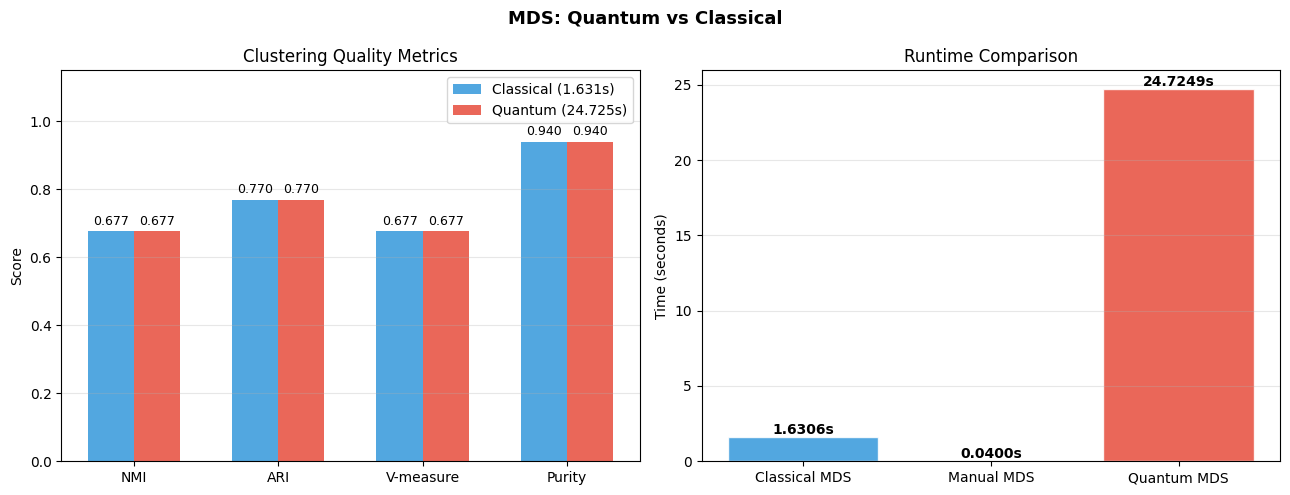

Saved: results/mds_metrics.png

任务完成！结果保存在 'results' 文件夹。


In [1]:
#经典 MDS 使用 sklearn 的迭代优化，其内部也是基于距离矩阵的双中心化与特征分解（与手动方法等价），因此理论上应与手动 MDS 结果一致。
#手动 MDS 直接对双中心化矩阵 B 进行特征分解，取最大的两个特征值和特征向量，再经 KMeans 聚类。
#量子 MDS 构造的目标是求解 B 的最大特征向量（对应第一主坐标），并将其降维后聚类。由于 B 的最大特征向量是唯一的（忽略符号），如果量子求解器能够精确找到该向量，那么聚类结果必然与手动 MDS 相同。

"""
基于特征值分解的衍生方法验证：多维缩放 (MDS) + 生物医药数据集
数据集：Breast Cancer Wisconsin (Diagnostic)（生物医药场景）

"""

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.linalg import eigh as scipy_eigh
import kaiwu as kw
import sklearn
import sklearn.cluster
import sklearn.metrics.cluster
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import time
import warnings
import os

warnings.filterwarnings("ignore")

# 新版1.3.1初始化（请替换为您的真实账号）
kw.license.init(user_id="121839779389169666", sdk_code="oTA7UoqEZJwLuHluYOHQ6kHss4NIkj")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results", exist_ok=True)

# ==================== 1. 加载生物医药数据集（乳腺癌） ====================
def load_breast_cancer_data():
    """
    加载乳腺癌数据集，二分类（良性/恶性），标准化并采样50条（各25条）
    """
    data = load_breast_cancer()
    X_raw = data.data
    y_raw = data.target
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    # 均匀采样50条（各25条），与原模板一致
    np.random.seed(66)
    idx0 = np.where(y_raw == 0)[0]   # 恶性
    idx1 = np.where(y_raw == 1)[0]   # 良性
    # 确保每类至少25个样本
    if len(idx0) >= 25 and len(idx1) >= 25:
        indices = np.concatenate([
            np.random.choice(idx0, 25, replace=False),
            np.random.choice(idx1, 25, replace=False)
        ])
    else:
        # 若不足则随机采样50个
        indices = np.random.choice(len(y_raw), 50, replace=False)
    X_normalized = X_scaled[indices]
    y_sample = y_raw[indices]
    print("采样后各类别样本数量：", np.bincount(y_sample))
    print("原始数据形状：", X_normalized.shape)
    print("使用的特征数量：", X_normalized.shape[1])
    return X_normalized, y_sample

X_normalized, y_sample = load_breast_cancer_data()

# ==================== 2. 经典 MDS（sklearn） + KMeans ====================
start_time_mds = time.time()
# MDS 降维到2维
mds = MDS(n_components=2, random_state=42, n_init=1, max_iter=300)
X_mds = mds.fit_transform(X_normalized)
kmeans_mds = KMeans(n_clusters=2, random_state=42, n_init=10)
label_mds = kmeans_mds.fit_predict(X_mds)
end_time_mds = time.time()
time_mds = end_time_mds - start_time_mds
print(f"经典MDS聚类标签: {label_mds}")
print(f"经典MDS耗时: {time_mds:.4f} 秒")
nmi_true_vs_mds = normalized_mutual_info_score(y_sample, label_mds)
print(f"真实标签 vs 经典MDS NMI: {nmi_true_vs_mds:.4f}")

# ==================== 3. 手动 MDS（特征值分解） ====================
# 手动实现经典MDS：计算距离矩阵 -> 双中心化 -> 特征分解 -> 取前2个特征向量作为坐标
start_time_manual = time.time()
# 计算欧氏距离平方矩阵
D_sq = cdist(X_normalized, X_normalized, metric='sqeuclidean')
n = D_sq.shape[0]
# 双中心化
one_n = np.ones((n, n)) / n
J = np.eye(n) - one_n   # 中心化矩阵
B = -0.5 * J @ D_sq @ J   # 内积矩阵
# 特征分解
eigvals, eigvecs = np.linalg.eigh(B)
# 取最大的2个特征值对应的特征向量（注意特征值是升序排列）
idx_desc = np.argsort(eigvals)[::-1]
coords = eigvecs[:, idx_desc[:2]] * np.sqrt(eigvals[idx_desc[:2]])   # 缩放得到坐标
# KMeans聚类
label_manual = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(coords)
end_time_manual = time.time()
time_manual = end_time_manual - start_time_manual
print(f"手动MDS耗时: {time_manual:.4f} 秒")
nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_manual)
print(f"手动MDS vs 真实标签 NMI: {nmi_manual_vs_true:.4f}")
nmi_manual_vs_mds = normalized_mutual_info_score(label_mds, label_manual)
print(f"手动MDS vs 经典MDS NMI: {nmi_manual_vs_mds:.4f}")

# ==================== 4. 量子 MDS（将最大特征向量问题转化为 QUBO） ====================
# 目标：求解双中心化矩阵 B 的最大特征向量（第一主坐标方向）
# 构造 H0 = I - B/λ_max，其最小特征向量对应 B 的最大特征向量
eigvals_sorted = eigvals[idx_desc]
lambda_max = eigvals_sorted[0] + 1e-8
H0 = np.eye(n) - B / lambda_max   # H0 的最小特征向量即为所需方向（n维）

# 后续处理与原谱聚类模板完全一致（只是输入矩阵变为 H0，维度 n x n）
Lambda = np.linalg.norm(H0, 1)
c = np.ones((n, 1)) / np.sqrt(n)
I_mat = np.eye(n)
H_shift = H0 - Lambda * I_mat + Lambda * (c @ c.T)   # 平移使最小特征值为负

# 构造 QUBO 矩阵
v = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
K = np.kron(I_mat, v)   # 形状 (n, n*len(v))
H = K.T @ H_shift @ K
cond_H = np.linalg.cond(H)
print(f'量子MDS矩阵条件数: {cond_H}')
H_min, H_max = np.min(H), np.max(H)
print(H_min, H_max)

# 线性缩放矩阵
H_scaled = ((H - H_min) / (H_max - H_min)) * (127 - (-128)) + (-128)
H_rounded = np.round(H_scaled)
H_clipped = np.clip(H_rounded, -128, 127)
H_qubo = kw.qubo.adjust_qubo_matrix_precision(H_clipped, bit_width=8)
print(H_qubo.shape)

# 转换为 Ising 模型
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(H_qubo)
n_vars = ising_mat.shape[0]
variables = [f"x[{i}]" for i in range(n_vars)]
ising_model = kw.ising.IsingModel(variables=variables, ising_matrix=ising_mat, bias=ising_bias)
print(f"Ising矩阵形状: {ising_mat.shape}")

# 提交任务到量子计算机
start_time_quantum = time.time()
optimizer = kw.cim.CIMOptimizer(task_name='breast_cancer_mds', task_mode='quota')
optimizer.solve(ising_model.get_matrix())
print("任务已提交，等待CIM计算...")

# 取回量子计算结果（轮询等待）
max_retries = 60
solution_ising = None
for attempt in range(max_retries):
    solution_ising = optimizer.solve(ising_model.get_matrix())
    if solution_ising is not None:
        print(f"CIM求解完成，返回解形状: {solution_ising.shape}")
        break
    time.sleep(2)
    print(f"等待CIM结果，已等待 {(attempt+1)*2} 秒...")
if solution_ising is None:
    raise TimeoutError("CIM求解超时")
end_time_quantum = time.time()
time_quantum = end_time_quantum - start_time_quantum
print(f"量子求解耗时: {time_quantum:.4f} 秒")

# 解码量子计算结果
solution = solution_ising[:, 0:solution_ising.shape[1]-1]
delta = solution_ising[:, -1]
solution = np.multiply(solution, delta.reshape(-1, 1))
solution = (solution + 1) / 2   # 二进制
solution_realnumber = K @ solution.T   # 形状 (n, numSolutions)

# 对每个候选解进行 KMeans 聚类（取第一个解作为最终结果）
numSolution = solution_realnumber.shape[1]
label_quantum = np.zeros((numSolution, n))
for i in range(numSolution):
    # 直接使用 solution_realnumber[:, i] 作为一维坐标（MDS 主坐标）
    coord = solution_realnumber[:, i]
    # 归一化
    coord_norm = (coord - np.min(coord)) / (np.max(coord) - np.min(coord) + 1e-8)
    # KMeans 聚类（与原模板一致）
    label_quantum[i, :] = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(coord_norm.reshape(-1, 1))
label_quantum_best = label_quantum[0, :]

hamiltonian = kw.common.hamiltonian(ising_model.get_matrix(), solution_ising)
print(f"哈密顿量: {hamiltonian}")

# ==================== 5. 评估指标函数 ====================
def purity_score(y_true, y_pred):
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

# ==================== 6. 打印所有评估结果 ====================
print("=" * 80)
print("乳腺癌数据 MDS 聚类结果评估")
print("=" * 80)

print("1. 与真实标签比较:")
print("-" * 40)

nmi_mds_vs_true = normalized_mutual_info_score(y_sample, label_mds)
ari_mds_vs_true = adjusted_rand_score(y_sample, label_mds)
v_measure_mds_vs_true = v_measure_score(y_sample, label_mds)
purity_mds_vs_true = purity_score(y_sample, label_mds)
print(f"经典MDS:")
print(f"  NMI:       {nmi_mds_vs_true:.4f}")
print(f"  ARI:       {ari_mds_vs_true:.4f}")
print(f"  V-measure: {v_measure_mds_vs_true:.4f}")
print(f"  纯度:      {purity_mds_vs_true:.4f}")
print(f"  耗时:      {time_mds:.4f} 秒")

nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_manual)
ari_manual_vs_true = adjusted_rand_score(y_sample, label_manual)
v_measure_manual_vs_true = v_measure_score(y_sample, label_manual)
purity_manual_vs_true = purity_score(y_sample, label_manual)
print(f"手动MDS:")
print(f"  NMI:       {nmi_manual_vs_true:.4f}")
print(f"  ARI:       {ari_manual_vs_true:.4f}")
print(f"  V-measure: {v_measure_manual_vs_true:.4f}")
print(f"  纯度:      {purity_manual_vs_true:.4f}")
print(f"  耗时:      {time_manual:.4f} 秒")

nmi_quantum_vs_true = normalized_mutual_info_score(y_sample, label_quantum_best)
ari_quantum_vs_true = adjusted_rand_score(y_sample, label_quantum_best)
v_measure_quantum_vs_true = v_measure_score(y_sample, label_quantum_best)
purity_quantum_vs_true = purity_score(y_sample, label_quantum_best)
print(f"量子MDS:")
print(f"  NMI:       {nmi_quantum_vs_true:.4f}")
print(f"  ARI:       {ari_quantum_vs_true:.4f}")
print(f"  V-measure: {v_measure_quantum_vs_true:.4f}")
print(f"  纯度:      {purity_quantum_vs_true:.4f}")
print(f"  耗时:      {time_quantum:.4f} 秒")

print("=" * 80)

# 汇总表
print("MDS 结果汇总表")
print("=" * 100)
print(f"{'方法':<20} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'耗时(秒)':<10}")
print("-" * 100)
print(f"{'经典MDS':<20} {nmi_mds_vs_true:<10.4f} {ari_mds_vs_true:<10.4f} {v_measure_mds_vs_true:<12.4f} {purity_mds_vs_true:<10.4f} {time_mds:<10.4f}")
print(f"{'手动MDS':<20} {nmi_manual_vs_true:<10.4f} {ari_manual_vs_true:<10.4f} {v_measure_manual_vs_true:<12.4f} {purity_manual_vs_true:<10.4f} {time_manual:<10.4f}")
print(f"{'量子MDS':<20} {nmi_quantum_vs_true:<10.4f} {ari_quantum_vs_true:<10.4f} {v_measure_quantum_vs_true:<12.4f} {purity_quantum_vs_true:<10.4f} {time_quantum:<10.4f}")
print("=" * 100)

# ==================== 7. 可视化（与原模板风格一致） ====================
# 使用 PCA 降维到2维进行散点图展示
from sklearn.decomposition import PCA
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_normalized)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MDS Clustering Comparison (Breast Cancer Wisconsin)", fontsize=14, fontweight="bold")

colors = ["#E74C3C", "#3498DB"]
plot_data = [
    (y_sample,              "Ground Truth"),
    (label_mds,             f"Classical MDS  NMI={nmi_mds_vs_true:.3f}  Time={time_mds:.3f}s"),
    (label_quantum_best,    f"Quantum MDS  NMI={nmi_quantum_vs_true:.3f}  Time={time_quantum:.3f}s"),
]

for ax, (labels, title) in zip(axes, plot_data):
    for c in range(2):
        idx_c = np.array(labels) == c
        ax.scatter(X_vis[idx_c, 0], X_vis[idx_c, 1],
                   c=colors[c], label=f"Class {c}", alpha=0.85, s=80,
                   edgecolors="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC1 (PCA of original features)")
    ax.set_ylabel("PC2 (PCA of original features)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/mds_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/mds_comparison.png")

# 指标条形图和耗时对比
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("MDS: Quantum vs Classical", fontsize=13, fontweight="bold")

metric_names = ["NMI", "ARI", "V-measure", "Purity"]
vals_classical = [nmi_mds_vs_true, ari_mds_vs_true, v_measure_mds_vs_true, purity_mds_vs_true]
vals_quantum   = [nmi_quantum_vs_true, ari_quantum_vs_true, v_measure_quantum_vs_true, purity_quantum_vs_true]

x = np.arange(len(metric_names))
width = 0.32
b1 = axes2[0].bar(x - width/2, vals_classical, width, label=f"Classical ({time_mds:.3f}s)", color="#3498DB", alpha=0.85)
b2 = axes2[0].bar(x + width/2, vals_quantum,  width, label=f"Quantum ({time_quantum:.3f}s)",   color="#E74C3C", alpha=0.85)
for bar in list(b1) + list(b2):
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(metric_names)
axes2[0].set_ylim(0, 1.15)
axes2[0].set_ylabel("Score")
axes2[0].set_title("Clustering Quality Metrics")
axes2[0].legend()
axes2[0].grid(True, axis="y", alpha=0.3)

# 时间对比
methods = ["Classical MDS", "Manual MDS", "Quantum MDS"]
times   = [time_mds, time_manual, time_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes2[1].bar(methods, times, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, t in zip(bars, times):
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes2[1].set_ylabel("Time (seconds)")
axes2[1].set_title("Runtime Comparison")
axes2[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/mds_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/mds_metrics.png")

print("\n任务完成！结果保存在 'results' 文件夹。")

In [2]:
# ==================== 8. MDS Proper Evaluation Metrics ====================
# MDS is dimensionality reduction — evaluate with:
# (a) Kruskal's Stress, (b) Distance matrix reconstruction error, (c) Explained variance

# Original distance matrix
D_original = np.sqrt(D_sq + 1e-12)

# Reconstruct distances from classical MDS (2D coords)
D_recon_mds = cdist(X_mds, X_mds, metric='euclidean')
D_recon_manual = cdist(coords, coords, metric='euclidean')

# Kruskal's Stress-1
stress_mds = np.sqrt(np.sum((D_original - D_recon_mds)**2) / np.sum(D_original**2))
stress_manual = np.sqrt(np.sum((D_original - D_recon_manual)**2) / np.sum(D_original**2))

# Quantum MDS: reconstruct from quantum solution (1D)
quantum_coord_1d = solution_realnumber[:, 0]
D_recon_quantum = cdist(quantum_coord_1d.reshape(-1, 1), quantum_coord_1d.reshape(-1, 1), metric='euclidean')
stress_quantum = np.sqrt(np.sum((D_original - D_recon_quantum)**2) / np.sum(D_original**2))

# Explained variance from eigenvalues of B
all_eigvals = np.sort(np.abs(eigvals))[::-1]
ev_ratio_manual = all_eigvals[:2] / np.sum(all_eigvals)
quantum_ev_ratio = all_eigvals[0] / np.sum(all_eigvals)

# Distance matrix reconstruction relative error
dist_err_mds = np.linalg.norm(D_original - D_recon_mds, 'fro') / np.linalg.norm(D_original, 'fro')
dist_err_manual = np.linalg.norm(D_original - D_recon_manual, 'fro') / np.linalg.norm(D_original, 'fro')
dist_err_quantum = np.linalg.norm(D_original - D_recon_quantum, 'fro') / np.linalg.norm(D_original, 'fro')

print("=" * 60)
print("MDS Proper Evaluation Metrics (Dimensionality Reduction)")
print("=" * 60)
print(f"Kruskal Stress (Classical MDS, 2D):   {stress_mds:.4f}")
print(f"Kruskal Stress (Manual MDS, 2D):      {stress_manual:.4f}")
print(f"Kruskal Stress (Quantum MDS, 1D):     {stress_quantum:.4f}")
print(f"Explained Variance (Manual, 2D):      {np.sum(ev_ratio_manual):.4f}")
print(f"Explained Variance (Quantum, 1D):     {quantum_ev_ratio:.4f}")
print(f"Distance Recon Error (Classical MDS):  {dist_err_mds:.4f}")
print(f"Distance Recon Error (Manual MDS):     {dist_err_manual:.4f}")
print(f"Distance Recon Error (Quantum MDS):    {dist_err_quantum:.4f}")


MDS Proper Evaluation Metrics (Dimensionality Reduction)
Kruskal Stress (Classical MDS, 2D):   0.1457
Kruskal Stress (Manual MDS, 2D):      0.2251
Kruskal Stress (Quantum MDS, 1D):     0.9340
Explained Variance (Manual, 2D):      0.7153
Explained Variance (Quantum, 1D):     0.5395
Distance Recon Error (Classical MDS):  0.1457
Distance Recon Error (Manual MDS):     0.2251
Distance Recon Error (Quantum MDS):    0.9340



MDS Proper Metrics Summary
Method               Stress       Expl.Var     Dist.Recon Err     Time (s)  
----------------------------------------------------------------------------------------------------
Classical MDS        0.1457       0.7153       0.1457             1.6306    
Manual MDS           0.2251       0.7153       0.2251             0.0400    
Quantum MDS          0.9340       0.5395       0.9340             24.7249   


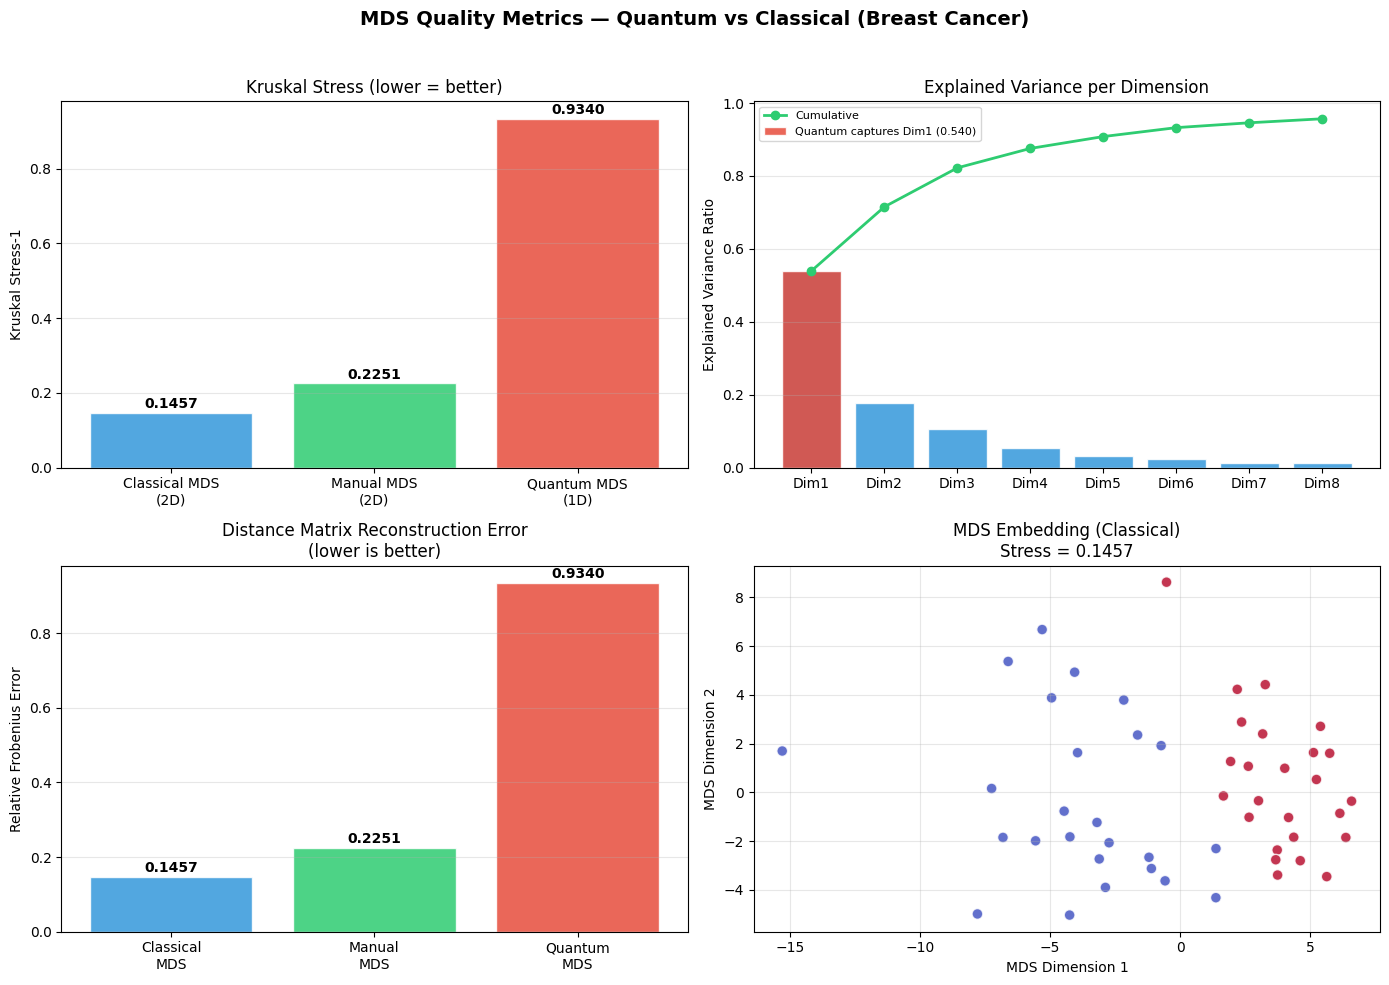

Saved: results/mds_proper_metrics.png


In [3]:
# ==================== 9. MDS Proper Metrics Summary + Plot ====================

# Summary table
print("\n" + "=" * 100)
print("MDS Proper Metrics Summary")
print("=" * 100)
print(f"{'Method':<20} {'Stress':<12} {'Expl.Var':<12} {'Dist.Recon Err':<18} {'Time (s)':<10}")
print("-" * 100)
print(f"{'Classical MDS':<20} {stress_mds:<12.4f} {np.sum(ev_ratio_manual):<12.4f} {dist_err_mds:<18.4f} {time_mds:<10.4f}")
print(f"{'Manual MDS':<20} {stress_manual:<12.4f} {np.sum(ev_ratio_manual):<12.4f} {dist_err_manual:<18.4f} {time_manual:<10.4f}")
print(f"{'Quantum MDS':<20} {stress_quantum:<12.4f} {quantum_ev_ratio:<12.4f} {dist_err_quantum:<18.4f} {time_quantum:<10.4f}")
print("=" * 100)

# 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MDS Quality Metrics — Quantum vs Classical (Breast Cancer)", fontsize=14, fontweight="bold", y=0.98)

# Subplot 1: Kruskal Stress
stress_labels = ["Classical MDS\n(2D)", "Manual MDS\n(2D)", "Quantum MDS\n(1D)"]
stress_values = [stress_mds, stress_manual, stress_quantum]
bars = axes[0, 0].bar(stress_labels, stress_values, color=["#3498DB", "#2ECC71", "#E74C3C"], alpha=0.85, edgecolor="white")
for bar, val in zip(bars, stress_values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0, 0].set_ylabel("Kruskal Stress-1")
axes[0, 0].set_title("Kruskal Stress (lower = better)")
axes[0, 0].grid(True, axis="y", alpha=0.3)

# Subplot 2: Explained Variance
n_top = min(8, len(all_eigvals))
ev_labels = [f"Dim{i+1}" for i in range(n_top)]
ev_ratios_all = all_eigvals[:n_top] / np.sum(all_eigvals)
axes[0, 1].bar(ev_labels, ev_ratios_all, color="#3498DB", alpha=0.85, edgecolor="white")
axes[0, 1].bar(ev_labels[0], ev_ratios_all[0], color="#E74C3C", alpha=0.85, edgecolor="white",
               label=f"Quantum captures Dim1 ({quantum_ev_ratio:.3f})")
axes[0, 1].plot(ev_labels, np.cumsum(ev_ratios_all), 'o-', color="#2ECC71", linewidth=2, markersize=6, label="Cumulative")
axes[0, 1].set_ylabel("Explained Variance Ratio")
axes[0, 1].set_title("Explained Variance per Dimension")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, axis="y", alpha=0.3)

# Subplot 3: Distance Matrix Reconstruction Error
dist_err_labels = ["Classical\nMDS", "Manual\nMDS", "Quantum\nMDS"]
dist_err_values = [dist_err_mds, dist_err_manual, dist_err_quantum]
bars = axes[1, 0].bar(dist_err_labels, dist_err_values, color=["#3498DB", "#2ECC71", "#E74C3C"], alpha=0.85, edgecolor="white")
for bar, val in zip(bars, dist_err_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1, 0].set_ylabel("Relative Frobenius Error")
axes[1, 0].set_title("Distance Matrix Reconstruction Error\n(lower is better)")
axes[1, 0].grid(True, axis="y", alpha=0.3)

# Subplot 4: MDS Embedding
axes[1, 1].scatter(X_mds[:, 0], X_mds[:, 1], c=y_sample, cmap="coolwarm", alpha=0.8, s=60, edgecolors="white")
axes[1, 1].set_xlabel("MDS Dimension 1")
axes[1, 1].set_ylabel("MDS Dimension 2")
axes[1, 1].set_title(f"MDS Embedding (Classical)\nStress = {stress_mds:.4f}")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("results/mds_proper_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/mds_proper_metrics.png")
